# Realtime multimodal Usecase | Extract Image,Table,Text from Document | MultiModal Summrizer| RAG App

In [ ]:
! pip install "unstructured[all-docs]" pillow pydantic lxml matplotlib

In [ ]:
!sudo apt-get update

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!sudo apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpoppler-dev libpoppler-private-dev libpoppler118
Recommended packages:
  poppler-data
The following NEW packages will be installed:
  poppler-utils
The following packages will be upgraded:
  libpoppler-dev libpoppler-private-dev libpoppler118
3 upgraded, 1 newly installed, 0 to remove and 87 not upgraded.
Need to get 1,471 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-private-dev amd64 22.02.0-2ubuntu0.13 [198 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-dev amd64 22.02.0-2ubuntu0.13 [5,186 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler118 amd64 22.02.0-2ubuntu0.13 [1,081 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 

In [ ]:
!sudo apt-get install libleptonica-dev tesseract-ocr libtesseract-dev python3-pil tesseract-ocr-eng tesseract-ocr-script-latn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
tesseract-ocr-eng set to manually installed.
The following additional packages will be installed:
  libarchive-dev libimagequant0 libraqm0 python3-olefile
Suggested packages:
  python-pil-doc
The following NEW packages will be installed:
  libarchive-dev libimagequant0 libleptonica-dev libraqm0 libtesseract-dev
  python3-olefile python3-pil tesseract-ocr-script-latn
0 upgraded, 8 newly installed, 0 to remove and 87 not upgraded.
Need to get 35.1 MB of archives.
After this operation, 107 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.7 [582 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libimagequant0 amd64 2.17.0-1 [34.6 kB]
Get:3 http://archive.ub

In [ ]:
!pip install unstructured-pytesseract
!pip install tesseract-ocr

  Preparing metadata (setup.py) ... done
  Created wheel for tesseract-ocr: filename=tesseract_ocr-0.0.1-cp312-cp312-linux_x86_64.whl size=188041 sha256=5f722c37103805998d39ab38cfe8df9be8942b4f511086f690d2b9fc0a435867
  Stored in directory: /root/.cache/pip/wheels/c4/96/8d/1e2b502793a5aa288a72ffdc5e96e9ebd22a72be6c0af195b5
Successfully built tesseract-ocr


In [ ]:
from unstructured.partition.pdf import partition_pdf

In [ ]:
partition_pdf?

In [ ]:
raw_pdf_elements=partition_pdf(
    filename="/content/data/cfg.pdf",
    strategy="hi_res", #Layout Detection Model
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir="extracted_data"
  )

In [ ]:

raw_pdf_elements

In [ ]:
Header=[]
Footer=[]
Title=[]
NarrativeText=[]
Text=[]
ListItem=[]


for element in raw_pdf_elements:
  if "unstructured.documents.elements.Header" in str(type(element)):
            Header.append(str(element))
  elif "unstructured.documents.elements.Footer" in str(type(element)):
            Footer.append(str(element))
  elif "unstructured.documents.elements.Title" in str(type(element)):
            Title.append(str(element))
  elif "unstructured.documents.elements.NarrativeText" in str(type(element)):
            NarrativeText.append(str(element))
  elif "unstructured.documents.elements.Text" in str(type(element)):
            Text.append(str(element))
  elif "unstructured.documents.elements.ListItem" in str(type(element)):
            ListItem.append(str(element))



In [ ]:
NarrativeText

['JAMIN BALL',
 "Every week I'll provide updates on the latest trends in cloud software companies. Follow along to stay up to date!",
 'OpenAI had their big developer day this week, and I wanted to call out two key announcements (and trends): increasing context windows and decreasing costs.',
 'When I think about the monetization of AI (and which “layers” monetize first) I’ve always thought it would follow the below order, with each layer lagging the one th comes before it.',
 "We've clearly well underway of the first 3 layers monetizing. Just starting the fourt layer, with the fifth layer showing up in some pockets, but not really widespread monetization (and I should clarify - scalable monetization). The caveat is importar",
 'https://cloudedjudgement.substack.com/p/clouded-judgement-111023',
 '1/14',
 "Ive heard of a well known company that had an offshore team handling lots of ma customer work (ie responses). And this “product” had a ~50% gross margin. When started using large lang

In [ ]:
Text

['NOV 10, 2023',
 'O42',
 '02',
 'G4',
 'S|',
 'EV / NTM Revenue Multiples',
 'ALTIME',
 'ALTIME™',
 'ALTIME',
 'EV / NTM Revenue',
 'ALTIME',
 '18x',
 '_FCF Multiple __',
 'Multiple_',
 'FCF Margin ___Ruleof40___LTM Operating Expenses % Rev',
 'LIM — Gross Operating',
 'Rev Growth',
 'Valuation',
 'GMAdj. _____Share Price Per',
 'Net',
 'https://cloudedjudgement.substack.com/p/clouded-judgement-111023',
 '(',
 '(',
 '¢',
 '(',
 '¢',
 '(',
 '«',
 '€',
 '(',
 '(',
 'i',
 'Type your email...',
 '} Subscribe',
 '@)D_D',
 'Comments _ Restacks',
 'Write a comment...',
 'any',
 '©']

In [ ]:
ListItem

['1. Raw silicon (chips like Nvidia bought in large quantities to build out infra to service upcoming demand).',
 '2. Model providers (OpenAI, Anthropic, etc as companies start building out Al).',
 '3. Hyperscalers (AWS, Azure, GCP as companies look for cloud GPUs who aren’ building out their own data centers)',
 '4. Infra (Data layer, orchestration, monitoring, ops, etc)',
 '5. Durable Applications',
 '1. Context length: Context window of GPT 4 Turbo went from 8k tokens to 128k tokens (think of this as ~300 pages of text worth of input). This means what yo can put into a prompt just went up dramatically',
 '2. Costs decreasing: GPT 4 Turbo is 3x cheaper for input tokens (think of this as roughly the length of the prompt) and 2x cheaper for output tokens. This equa to $0.01 per 1k input tokens, and $0.03 per 1k output tokens. On a blended bas GPT 4 Turbo is roughly 2.5-3x cheaper than GPT 4.',
 "e “Tt looks like we've hit an inflection point. It looks like there's a lot less overhang n

In [ ]:
img=[]
for element in raw_pdf_elements:
  if "unstructured.documents.elements.Image" in str(type(element)):
            img.append(str(element))

In [ ]:
len(img)

11

In [ ]:
img[7]

'60.0% 50.0% 40.0% 30.0% 70.0% 20.0% 10.0% Ox afifis 1/1/16 11/17 1/1/18 ween FCF Positive & <100x Multiple Median Glouded Judgement @jaminball 1/1/20 1/1/21 es |] Average Afif22 1/1/23 ALTIME'

In [ ]:
raw_pdf_elements2=partition_pdf(
    filename="/content/data/research_paper.pdf",
    strategy="hi_res",
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir="extracted_data2"
  )

In [ ]:
raw_pdf_elements2

In [ ]:
img=[]
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.Image" in str(type(element)):
            img.append(str(element))

In [ ]:
img

['Define "middle ear"(x)  Question Answering:  End-to-End Backprop through q and\xa0pθ  The middle ear includes  the tympanic cavity and  the three ossicles.  (y)  Question Query  Barack Obama was  born in Hawaii.(x)  Query  Encoder  q(x)  Retriever pη  (Non-Parametric)  Document  Index  d(z)  z4  Generator\xa0pθ  (Parametric)  Question Answering:  Answer Generation  supports (y)  Fact Veriﬁcation: Fact Query  z2  z3  Margin-  alize  Fact Veriﬁcation:  Label Generation  The Divine  Comedy (x)  q  MIPS  z1  pθ  This 14th century work  is divided into 3  Jeopardy Question  sections: "Inferno",  Generation:  Answer Query  "Purgatorio" &  "Paradiso"         (y)  Question Generation ',
 '',
 'h  c  t  a  M  t  c  a  x  E  Q  N  44  43  42  41  40  39  RAG-Tok  RAG-Seq  K  @  l  l  a  c  e  R  r  e  w  s  n  A  Q  N  80  70  60  50  40  RAG-Tok  RAG-Seq  Fixed DPR  BM25  e  r  o  c  s  L  -  e  g  u  o  R  /  1  -  u  e  l  B  56  54  52  50  48  RAG-Tok R-L  RAG-Tok B-1  RAG-Seq R-L  RAG-Se

In [ ]:
tab=[]
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.Table" in str(type(element)):
            tab.append(str(element))

In [ ]:
tab[0]

'Closed Book T5-11B [52] 34.5 T5-11B+SSM[52] 36.6 - - /50.1 37.4 /60.5 44.7 - - Model Jeopardy MSMARCO FVR3 FVR2 B-1 QB-1 R-L B-1 Label Acc. Open REALM [20] 40.4 - / - 40.7 46.8 SotA - - 49.8* 49.9* 76.8 Book DPR [26] 41.5 57.9/ - 41.1 50.6 BART 15.1 19.7 38.2 41.6 64.0 81.1 RAG-Token RAG-Seq. 44.1 55.2/66.1 45.5 50.0 44.5 56.8/68.0 45.2 52.2 RAG-Tok. 17.3 22.2 RAG-Seq. 14.7 21.4 40.1 40.8 41.5 44.2 72.5 89.5'

In [ ]:
NarrativeText=[]
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.NarrativeText" in str(type(element)):
            NarrativeText.append(str(element))

In [ ]:
ListItem=[]
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.ListItem" in str(type(element)):
            ListItem.append(str(element))

In [ ]:
NarrativeText


["Patrick Lewis'?, Ethan Perez*,",
 'Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†',
 '‘Facebook AI Research; *University College London; *New York University;',
 'plewis@fb.com',
 'Large pre-trained language models have been shown to store factual knowledge in their parameters, and achieve state-of-the-art results when ﬁne-tuned on down- stream NLP tasks. However, their ability to access and precisely manipulate knowl- edge is still limited, and hence on knowledge-intensive tasks, their performance lags behind task-speciﬁc architectures. Additionally, providing provenance for their decisions and updating their world knowledge remain open research problems. Pre- trained models with a differentiable access mechanism to explicit non-parametric memory have so far been only investigated for extractive downstream tasks. We explore a general-purpose ﬁne-tuning recipe for retrieval-augmented generation (RAG) — models which combine pre-trained parametric and no

In [ ]:
ListItem

['[1] Payal Bajaj, Daniel Campos, Nick Craswell, Li Deng, Jianfeng Gao, Xiaodong Liu, Rangan Majumder, Andrew McNamara, Bhaskar Mitra, Tri Nguyen, Mir Rosenberg, Xia Song, Alina Stoica, Saurabh Tiwary, and Tong Wang. MS MARCO: A Human Generated MAchine Reading COmprehension Dataset. arXiv:1611.09268 [cs], November 2016. URL http: //arxiv.org/abs/1611.09268. arXiv: 1611.09268.',
 '[2] Petr Baudiš and Jan Šediv`y. Modeling of the question answering task in the yodaqa system. In International Conference of the Cross-Language Evaluation Forum for European Languages, pages 222–228. Springer, 2015. URL https://link.springer.com/chapter/10.1007% 2F978-3-319-24027-5_20.',
 '[3] Jonathan Berant, Andrew Chou, Roy Frostig, and Percy Liang. Semantic Parsing on Freebase from Question-Answer Pairs. In Proceedings of the 2013 Conference on Empirical Methods in Natural Language Processing, pages 1533–1544, Seattle, Washington, USA, October 2013. Association for Computational Linguistics. URL http://ww

In [ ]:
!pip install langchain_core

In [ ]:
!pip install langchain_openai

In [ ]:
len(tab)

5

In [ ]:
tab

['Closed Book T5-11B [52] 34.5 T5-11B+SSM[52] 36.6 - - /50.1 37.4 /60.5 44.7 - - Model Jeopardy MSMARCO FVR3 FVR2 B-1 QB-1 R-L B-1 Label Acc. Open REALM [20] 40.4 - / - 40.7 46.8 SotA - - 49.8* 49.9* 76.8 Book DPR [26] 41.5 57.9/ - 41.1 50.6 BART 15.1 19.7 38.2 41.6 64.0 81.1 RAG-Token RAG-Seq. 44.1 55.2/66.1 45.5 50.0 44.5 56.8/68.0 45.2 52.2 RAG-Tok. 17.3 22.2 RAG-Seq. 14.7 21.4 40.1 40.8 41.5 44.2 72.5 89.5',
 'MS- deﬁne middle ear BART ?The middle ear is the part of the ear between the middle ear and the nose. RAG-T The middle ear is the portion of the ear internal to the eardrum. RAG-S The middle ear includes the tympanic cavity and the three ossicles. MARCO what currency BART The currency needed in Scotland is Pound sterling. needed in RAG-T Pound is the currency needed in Scotland. scotland RAG-S The currency needed in Scotland is the pound sterling. BART ?This state has the largest number of counties in the U.S. Jeopardy Washington RAG-T It’s the only U.S. state named for a U.S

In [ ]:
tab[0]

'Closed Book T5-11B [52] 34.5 T5-11B+SSM[52] 36.6 - - /50.1 37.4 /60.5 44.7 - - Model Jeopardy MSMARCO FVR3 FVR2 B-1 QB-1 R-L B-1 Label Acc. Open REALM [20] 40.4 - / - 40.7 46.8 SotA - - 49.8* 49.9* 76.8 Book DPR [26] 41.5 57.9/ - 41.1 50.6 BART 15.1 19.7 38.2 41.6 64.0 81.1 RAG-Token RAG-Seq. 44.1 55.2/66.1 45.5 50.0 44.5 56.8/68.0 45.2 52.2 RAG-Tok. 17.3 22.2 RAG-Seq. 14.7 21.4 40.1 40.8 41.5 44.2 72.5 89.5'

In [ ]:
len(img)

4

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

In [ ]:
# Prompt
prompt_text = """You are an assistant tasked with summarizing tables for retrieval. \
    These summaries will be embedded and used to retrieve the raw table elements. \
    Give a concise summary of the table that is well optimized for retrieval. Table {element} """

In [ ]:
prompt = ChatPromptTemplate.from_template(prompt_text)

In [ ]:
import os
from google.colab import userdata
OPENAI_API_TOKEN=userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_TOKEN

In [ ]:
# Text summary chain
model = ChatOpenAI(temperature=0, model="gpt-4o")

In [ ]:
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [ ]:
table_summaries = []

In [ ]:
table_summaries=summarize_chain.batch(tab,{"max_concurrency": 5})

In [ ]:
tab[0]

'Closed Book T5-11B [52] 34.5 T5-11B+SSM[52] 36.6 - - /50.1 37.4 /60.5 44.7 - - Model Jeopardy MSMARCO FVR3 FVR2 B-1 QB-1 R-L B-1 Label Acc. Open REALM [20] 40.4 - / - 40.7 46.8 SotA - - 49.8* 49.9* 76.8 Book DPR [26] 41.5 57.9/ - 41.1 50.6 BART 15.1 19.7 38.2 41.6 64.0 81.1 RAG-Token RAG-Seq. 44.1 55.2/66.1 45.5 50.0 44.5 56.8/68.0 45.2 52.2 RAG-Tok. 17.3 22.2 RAG-Seq. 14.7 21.4 40.1 40.8 41.5 44.2 72.5 89.5'

In [ ]:
table_summaries[0]

'The table compares various models on different tasks, including Jeopardy, MSMARCO, FVR3, FVR2, B-1, QB-1, R-L, and Label Accuracy. Key models include Closed Book T5-11B, T5-11B+SSM, Open REALM, DPR, BART, RAG-Token, and RAG-Sequence. Performance metrics are provided for each model, with notable scores such as T5-11B+SSM achieving 36.6 on Jeopardy, REALM reaching 40.7 on MSMARCO, and DPR scoring 57.9 on MSMARCO. RAG-Token and RAG-Sequence show competitive results across multiple tasks, with RAG-Seq. achieving 68.0 on QB-1. The table highlights the state-of-the-art (SotA) performance with REALM and DPR models, and includes specific scores for B-1 and Label Accuracy tasks.'

In [ ]:
NarrativeText

["Patrick Lewis'?, Ethan Perez*,",
 'Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†',
 '‘Facebook AI Research; *University College London; *New York University;',
 'plewis@fb.com',
 'Large pre-trained language models have been shown to store factual knowledge in their parameters, and achieve state-of-the-art results when ﬁne-tuned on down- stream NLP tasks. However, their ability to access and precisely manipulate knowl- edge is still limited, and hence on knowledge-intensive tasks, their performance lags behind task-speciﬁc architectures. Additionally, providing provenance for their decisions and updating their world knowledge remain open research problems. Pre- trained models with a differentiable access mechanism to explicit non-parametric memory have so far been only investigated for extractive downstream tasks. We explore a general-purpose ﬁne-tuning recipe for retrieval-augmented generation (RAG) — models which combine pre-trained parametric and no

In [ ]:
# Prompt
prompt_text = """You are an assistant tasked with summarizing text for retrieval. \
    These summaries will be embedded and used to retrieve the raw text elements. \
    Give a concise summary of the table or text that is well optimized for retrieval.text: {element} """


prompt = ChatPromptTemplate.from_template(prompt_text)
# Text summary chain
model = ChatOpenAI(temperature=0, model="gpt-4o")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

text_summaries = []

text_summaries = summarize_chain.batch(NarrativeText, {"max_concurrency": 5})

In [ ]:
text_summaries

['The text mentions two individuals, Patrick Lewis and Ethan Perez.',
 'Authors: Mike Lewis, Wen-tau Yih, Tim Rocktäschel, Sebastian Riedel, Douwe Kiela. Affiliations: †Primary affiliation, ‡Secondary affiliation.',
 'Collaboration between Facebook AI Research, University College London, and New York University.',
 'Email address: plewis@fb.com',
 'This text discusses the limitations of large pre-trained language models in accessing and manipulating knowledge, particularly in knowledge-intensive tasks. It introduces Retrieval-Augmented Generation (RAG) models, which combine pre-trained parametric memory with non-parametric memory, using a seq2seq model and a dense vector index of Wikipedia accessed by a neural retriever. Two RAG formulations are compared: one using the same retrieved passages for the entire sequence and another using different passages per token. RAG models are fine-tuned and evaluated on various NLP tasks, achieving state-of-the-art results in open domain QA tasks and

In [ ]:
img[0]

'Define "middle ear"(x)  Question Answering:  End-to-End Backprop through q and\xa0pθ  The middle ear includes  the tympanic cavity and  the three ossicles.  (y)  Question Query  Barack Obama was  born in Hawaii.(x)  Query  Encoder  q(x)  Retriever pη  (Non-Parametric)  Document  Index  d(z)  z4  Generator\xa0pθ  (Parametric)  Question Answering:  Answer Generation  supports (y)  Fact Veriﬁcation: Fact Query  z2  z3  Margin-  alize  Fact Veriﬁcation:  Label Generation  The Divine  Comedy (x)  q  MIPS  z1  pθ  This 14th century work  is divided into 3  Jeopardy Question  sections: "Inferno",  Generation:  Answer Query  "Purgatorio" &  "Paradiso"         (y)  Question Generation '

In [ ]:
import base64
import os
from langchain_core.messages import HumanMessage

In [ ]:
def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [ ]:
def image_summarize(img_base64, prompt):
    """Make image summary"""


    chat = ChatOpenAI(model="gpt-4o", max_tokens=1024)

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},

                     {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content

In [ ]:
def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval. \
    These summaries will be embedded and used to retrieve the raw image. \
    Give a concise summary of the image that is well optimized for retrieval."""


    base64_image = encode_image(path)
    print(base64_image)
    img_base64_list.append(base64_image)
    image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries

In [ ]:
fpath="/content/extracted_data2/figure-2-1.jpg"

In [ ]:
img_base64_list,image_summaries=generate_img_summaries(fpath)

...


In [ ]:
image_summaries[0]

'Diagram illustrating a Q&A system with end-to-end backpropagation. Components include a Query Encoder handling queries like defining "middle ear" and verifying facts. A non-parametric retriever processes encoded queries using approximate maximum inner product search (MIPS) to access a document index. A parametric generator produces responses or labels, leveraging backpropagation through both the retriever and generator for tasks such as answer generation and fact verification, using examples like "The Divine Comedy" and Barack Obama\'s birthplace.'

# Creating a MultiVector Retriever

In [ ]:
!pip install langchain_community

In [ ]:
!pip install chromadb

In [ ]:
!pip install langchain

In [ ]:
!pip install langchain_openai openai

In [ ]:
import uuid

from langchain_classic.retrievers import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

/tmp/ipykernel_4165/1139077721.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


In [ ]:
def create_multi_vector_retriever(vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """

    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )


    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):

      doc_ids = [str(uuid.uuid4()) for _ in doc_contents]

      summary_docs = [
              Document(page_content=s, metadata={id_key: doc_ids[i]})
              for i, s in enumerate(doc_summaries)
          ]

      retriever.vectorstore.add_documents(summary_docs)
      retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    # Add texts, tables, and images
    # Check that text_summaries is not empty before adding
    if text_summaries:
        add_documents(retriever, text_summaries, texts)
    # Check that table_summaries is not empty before adding
    if table_summaries:
        add_documents(retriever, table_summaries, tab)
    # Check that image_summaries is not empty before adding
    if image_summaries:
        add_documents(retriever, image_summaries, img)

    return retriever

vectorstore = Chroma(
    collection_name="mm_rag", embedding_function=OpenAIEmbeddings()
)

# Create retriever
retriever_multi_vector_img = create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    NarrativeText,
    table_summaries,
    tab,
    image_summaries,
    img_base64_list,
)

/tmp/ipykernel_4165/70246668.py:44: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [ ]:
retriever_multi_vector_img

MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7b0d9832f4d0>, docstore=<langchain_core.stores.InMemoryStore object at 0x7b0d95e15f10>, search_kwargs={})

In [ ]:
import io
import re

from IPython.display import HTML, display
from PIL import Image

In [ ]:
def plt_img_base64(img_base64):
    """Disply base64 encoded string as image"""
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # Display the image by rendering the HTML
    display(HTML(image_html))



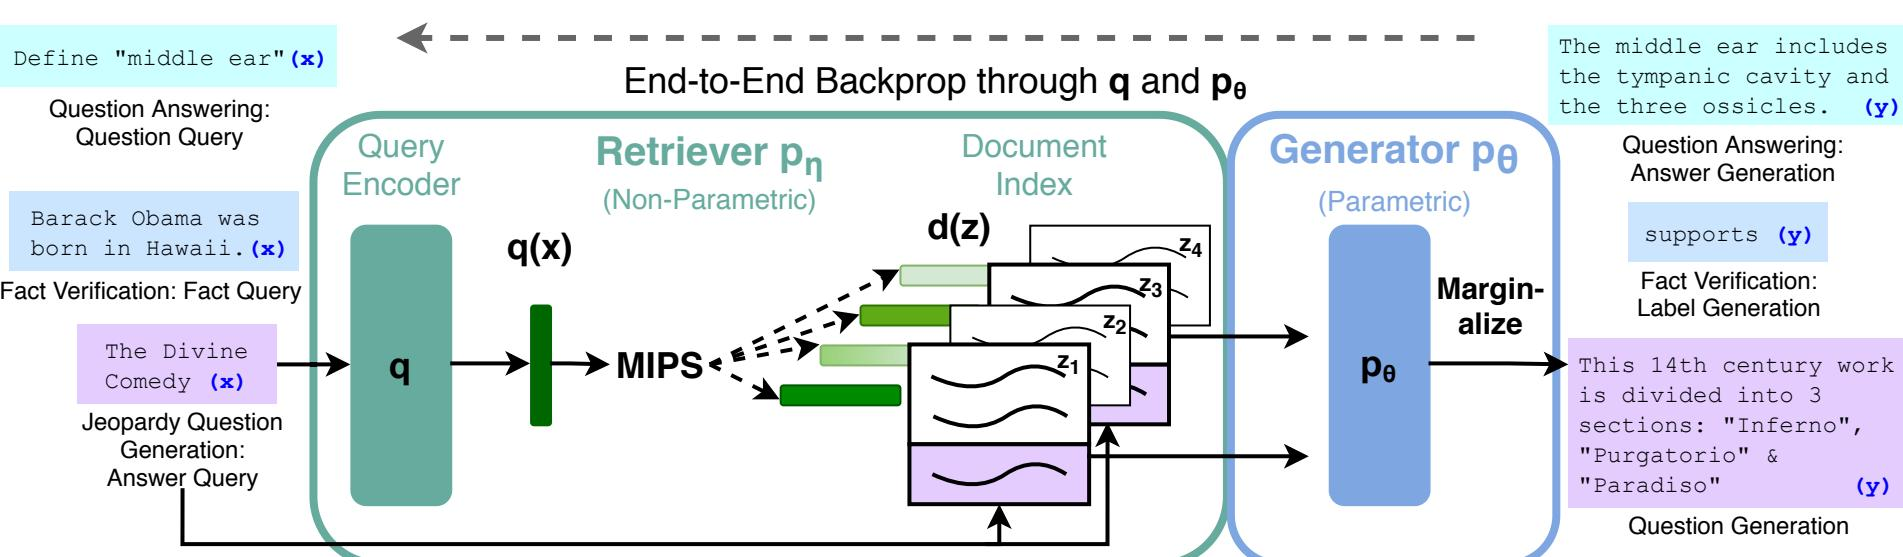

In [ ]:
plt_img_base64(img_base64_list[0])

In [ ]:
image_summaries[0]

'Diagram illustrating a Q&A system with end-to-end backpropagation. Components include a Query Encoder handling queries like defining "middle ear" and verifying facts. A non-parametric retriever processes encoded queries using approximate maximum inner product search (MIPS) to access a document index. A parametric generator produces responses or labels, leveraging backpropagation through both the retriever and generator for tasks such as answer generation and fact verification, using examples like "The Divine Comedy" and Barack Obama\'s birthplace.'

In [ ]:
def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None


In [ ]:
def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xFF\xD8\xFF": "jpg",
        b"\x89\x50\x4E\x47\x0D\x0A\x1A\x0A": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False

In [ ]:
def resize_base64_image(base64_string, size=(128, 128)):
    """
    Resize an image encoded as a Base64 string
    """
    # Decode the Base64 string
    img_data = base64.b64decode(base64_string)
    img = Image.open(io.BytesIO(img_data))

    # Resize the image
    resized_img = img.resize(size, Image.LANCZOS)

    # Save the resized image to a bytes buffer
    buffered = io.BytesIO()
    resized_img.save(buffered, format=img.format)

    # Encode the resized image to Base64
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

In [ ]:
def split_image_text_types(docs):
    """
    Split base64-encoded images and texts
    """
    b64_images = []
    texts = []

    for doc in docs:
        # Check if the document is of type Document and extract page_content if so
        if isinstance(doc, Document):
            doc = doc.page_content
        if looks_like_base64(doc) and is_image_data(doc):
            doc = resize_base64_image(doc, size=(1300, 600))
            b64_images.append(doc)
        else:
            texts.append(doc)

    return {"images": b64_images, "texts": texts}

In [ ]:
def img_prompt_func(data_dict):
    """
    Join the context into a single string
    """

    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text for analysis
    text_message = {
        "type": "text",
        "text": (
            "You are a helpful assistant.\n"
            "You will be given a mixed info(s) .\n"
            "Use this information to provide relevant information to the user question. \n"
            f"User-provided question: {data_dict['question']}\n\n"
            "Text and / or tables:\n"
            f"{formatted_texts}"
        ),
    }
    messages.append(text_message)

    return [HumanMessage(content=messages)]

In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [ ]:
def multi_modal_rag_chain(retriever):
    """
    Multi-modal RAG chain
    """

    # Multi-modal LLM
    model = ChatOpenAI(temperature=0, model="gpt-4o", max_tokens=1024)


    # RAG pipeline
    chain = (
        {
            "context": retriever_multi_vector_img | RunnableLambda(split_image_text_types),
            "question": RunnablePassthrough(),
        }
        | RunnableLambda(img_prompt_func)
        | model
        | StrOutputParser()
    )

    return chain

In [ ]:
# Create RAG chain
chain_multimodal_rag = multi_modal_rag_chain(retriever_multi_vector_img)

In [ ]:
chain_multimodal_rag

{
  context: MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7b0d9832f4d0>, docstore=<langchain_core.stores.InMemoryStore object at 0x7b0d95e15f10>, search_kwargs={})
           | RunnableLambda(split_image_text_types),
  question: RunnablePassthrough()
}
| RunnableLambda(img_prompt_func)
| ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.6', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_mes

In [ ]:
query="can you explain me this Left: NQ performance as more documents are retrieved. Center: Retrieval recall performance\
in NQ. Right: MS-MARCO Bleu-1 and Rouge-L as more documents are retrieved."

In [ ]:
# Run RAG chain
chain_multimodal_rag.invoke(query)

'The information provided discusses the impact of retrieving more documents on the performance of models in different tasks, specifically focusing on Open-domain Question Answering (QA) and MS-MARCO, a benchmark dataset for evaluating machine reading comprehension and retrieval tasks.\n\n1. **Left: NQ Performance as More Documents are Retrieved**:\n   - The text mentions that models are trained with either 5 or 10 retrieved latent documents, and there are no significant differences in performance between these two settings during training.\n   - However, at test time, retrieving more documents can affect both performance and runtime.\n   - For the RAG-Sequence model, retrieving more documents at test time monotonically improves Open-domain QA results, meaning that performance continues to improve as more documents are retrieved.\n   - In contrast, for the RAG-Token model, performance peaks when 10 documents are retrieved, suggesting that retrieving more than 10 documents does not lead 

In [ ]:
query="Explain the overview of the approach taken of Query Encoder + Document Index "

In [ ]:
# Run RAG chain
chain_multimodal_rag.invoke(query)

"The approach of using a Query Encoder combined with a Document Index is a method designed to efficiently retrieve and utilize information from a large corpus of documents. Here's an overview of how this approach works:\n\n1. **Document Index as Non-Parametric Memory**: \n   - The document index acts as a large external memory that stores raw text documents. This is similar to memory networks, where the model can attend to this memory to retrieve relevant information.\n   - The memory is human-readable and writable, allowing for dynamic updates by editing the document index. This provides interpretability and flexibility.\n\n2. **Query Encoder**:\n   - A query encoder, based on a model like BERTBASE, is used to produce a dense representation of the input query. This representation is crucial for retrieving relevant documents from the index.\n\n3. **Document Encoder**:\n   - Similarly, a document encoder, also based on BERTBASE, generates dense representations for documents in the index

# CLIP Model

In [ ]:
%pip install --upgrade --quiet  langchain-experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 16.2 MB/s eta 0:00:00


In [ ]:
%pip install --upgrade --quiet  pillow open_clip_torch torch matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 k

In [ ]:
import numpy as np
from langchain_experimental.open_clip import OpenCLIPEmbeddings
from PIL import Image

# Image URIs
uri_chart_1 = "/content/extracted_data2/figure-2-1.jpg"
uri_chart_2 = "/content/extracted_data2/figure-8-3.jpg"

# Embe images or text
clip_embd = OpenCLIPEmbeddings(model_name="ViT-B-32", checkpoint="laion2b_s34b_b79k")
img_feat_chart_1 = clip_embd.embed_image([uri_chart_1])
img_feat_chart_2 = clip_embd.embed_image([uri_chart_2])
text_feat_chart_1 = clip_embd.embed_documents(["chart_1"])
text_feat_chart_2 = clip_embd.embed_documents(["chart_2"])

/tmp/ipykernel_4165/681767433.py:2: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.open_clip import OpenCLIPEmbeddings


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [ ]:
text_feat_chart_1

[[0.049601707607507706,
  -0.020078860223293304,
  -0.006002527195960283,
  -0.028166502714157104,
  -0.028098072856664658,
  -0.045190952718257904,
  -0.0008947253809310496,
  0.023927781730890274,
  0.039646245539188385,
  -0.005238388665020466,
  -0.011629270389676094,
  0.0248701274394989,
  -0.016809964552521706,
  0.015525954775512218,
  -0.016617480665445328,
  -0.030103512108325958,
  -0.16593416035175323,
  -0.039196670055389404,
  -0.013950228691101074,
  -0.02033073641359806,
  0.026533713564276695,
  0.006540060508996248,
  -0.006733188405632973,
  -0.003453534096479416,
  -0.026618272066116333,
  -0.014899900183081627,
  0.06101347506046295,
  -0.02909420244395733,
  -0.0061649843119084835,
  0.030285868793725967,
  0.004343506880104542,
  -0.014835619367659092,
  -0.03434332460165024,
  -0.012930111028254032,
  0.0184992216527462,
  -0.016473839059472084,
  0.011431551538407803,
  0.025147929787635803,
  0.006703613791614771,
  -0.023075111210346222,
  -0.0144746964797377

In [ ]:
img_feat_chart_1

[[0.04763669893145561,
  -0.21187502145767212,
  0.0489208810031414,
  0.031596213579177856,
  -0.07637225836515427,
  -0.04220377653837204,
  -0.01210691500455141,
  -0.010052037425339222,
  0.010250689461827278,
  0.048065099865198135,
  0.01017468050122261,
  -0.025926275178790092,
  0.006387670990079641,
  -0.052759766578674316,
  0.060781314969062805,
  0.001541019300930202,
  -0.042271241545677185,
  -0.032311972230672836,
  -0.05184371396899223,
  -0.019549455493688583,
  -0.04015578329563141,
  0.06746621429920197,
  0.03850395977497101,
  -0.018817130476236343,
  0.00627489760518074,
  -0.05513549596071243,
  -0.004076323937624693,
  0.045010071247816086,
  0.0463147833943367,
  -0.05626711621880531,
  0.03875751420855522,
  0.014930827543139458,
  0.01793634332716465,
  0.015858855098485947,
  -0.07185874879360199,
  -0.03870934620499611,
  -0.06625641882419586,
  -0.05395877733826637,
  0.025071093812584877,
  0.0076476698741316795,
  0.04165539890527725,
  0.026528662070631

In [ ]:
len(img_feat_chart_1[0])

512

In [ ]:
text_feat_chart_1

[[0.049601707607507706,
  -0.020078860223293304,
  -0.006002527195960283,
  -0.028166502714157104,
  -0.028098072856664658,
  -0.045190952718257904,
  -0.0008947253809310496,
  0.023927781730890274,
  0.039646245539188385,
  -0.005238388665020466,
  -0.011629270389676094,
  0.0248701274394989,
  -0.016809964552521706,
  0.015525954775512218,
  -0.016617480665445328,
  -0.030103512108325958,
  -0.16593416035175323,
  -0.039196670055389404,
  -0.013950228691101074,
  -0.02033073641359806,
  0.026533713564276695,
  0.006540060508996248,
  -0.006733188405632973,
  -0.003453534096479416,
  -0.026618272066116333,
  -0.014899900183081627,
  0.06101347506046295,
  -0.02909420244395733,
  -0.0061649843119084835,
  0.030285868793725967,
  0.004343506880104542,
  -0.014835619367659092,
  -0.03434332460165024,
  -0.012930111028254032,
  0.0184992216527462,
  -0.016473839059472084,
  0.011431551538407803,
  0.025147929787635803,
  0.006703613791614771,
  -0.023075111210346222,
  -0.0144746964797377

In [ ]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from matplotlib import pyplot as plt

# Initialize ChromaDB client
chroma_client = chromadb.PersistentClient(path="my_vectordb")

# Initialize ImageLoader and EmbeddingFunction
image_loader = ImageLoader()
multimodal_ef = OpenCLIPEmbeddingFunction()

In [ ]:
multimodal_db = chroma_client.get_or_create_collection(
    name="multimodal_db",
    embedding_function=multimodal_ef,
    data_loader=image_loader
)

# Add images to the database
multimodal_db.add(
#ensure each image has an unique id.
    ids=['0', '1'],
    uris=[
        '/content/extracted_data2/figure-2-1.jpg', '/content/extracted_data2/figure-8-3.jpg'
    ],
#the metadatas below contains imagecategory only , we can add more variables.
    metadatas=[
        {'img_category': 'charts'}, {'img_category': 'charts'}
    ]
)

In [ ]:
query_texts = ['Query Encoder + Document Index']

query_results = multimodal_db.query(
    query_texts = query_texts,
    n_results=1,
    include=['documents', 'distances', 'metadatas', 'data', 'uris'],
    where={'img_category':'charts'}
)

In [ ]:
query_results

{'ids': [['0']],
 'embeddings': None,
 'documents': [[None]],
 'uris': [['/content/extracted_data2/figure-2-1.jpg']],
 'included': ['documents', 'distances', 'metadatas', 'data', 'uris'],
 'data': [[array([[[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          ...,
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          [[255, 255, 255],
 

In [ ]:
def print_query_results(query_list: list, query_results: dict) -> None:
    result_count = len(query_results['ids'][0])

    for i in range(len(query_list)):
        print(f'Results for query: {query_list[i]}')

        for j in range(result_count):
            id = query_results["ids"][i][j]
            distance = query_results['distances'][i][j]
            data = query_results['data'][i][j]
            metadata = query_results['metadatas'][i][j]
            document = query_results['documents'][i][j]
            uri = query_results['uris'][i][j]

            print(f'id: {id}, distance: {distance}, document: {document}')
            print(f'data: {uri}')
            plt.imshow(data)
            plt.axis("off")
            plt.show()



Results for query: Query Encoder + Document Index
id: 0, distance: 0.7168184518814087, document: None
data: /content/extracted_data2/figure-2-1.jpg


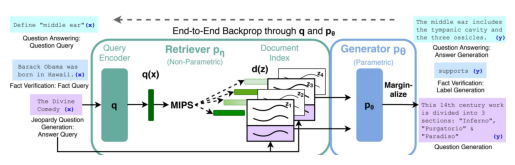

In [ ]:
print_query_results(query_texts, query_results)

In [ ]:
query_texts = ['What is the effect of retrieving more documents on recall and L Score']

query_results = multimodal_db.query(
    query_texts = query_texts,
    n_results=1,
    include=['documents', 'distances', 'metadatas', 'data', 'uris'],
    where={'img_category':'charts'}
)

Results for query: What is the effect of retrieving more documents on recall and L Score
id: 1, distance: 0.760332465171814, document: None
data: /content/extracted_data2/figure-8-3.jpg


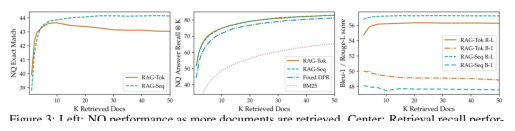

In [ ]:
print_query_results(query_texts, query_results)